# AAE722 Final Project: Airbnb Price Prediction

**Project Title:** Predicting Airbnb Listing Prices Using Machine Learning: A Regression Approach

**Author:** Hantian Ye (Kingsley)

This notebook implements an end-to-end machine learning pipeline for predicting Airbnb listing prices in NYC.

## Pipeline Overview

1. **Data Loading & Cleaning**: Download and preprocess Inside Airbnb NYC data
2. **Feature Engineering**: Create features including spatial grid for group-based splits
3. **Spatial Group-Based Splitting**: Prevent geographic leakage using GroupShuffleSplit
4. **Model Training**: Three models - Ridge, GBM (LightGBM/XGBoost), Deep Learning
5. **Evaluation**: RMSE/MAE on both log-price and back-transformed price
6. **Interpretability**: SHAP for tree models, Permutation Importance for DL
7. **Export Artifacts**: All plots, CSVs, and model files saved to `_airbnb_plots/`


In [40]:
# Import libraries and set up configuration
import os
import json
import warnings
import sys
warnings.filterwarnings('ignore')

# Check NumPy version and handle compatibility issues
try:
    import numpy as np
    numpy_version = np.__version__
    print(f"NumPy version: {numpy_version}")
    
    # Check if NumPy 2.x (may cause compatibility issues)
    if numpy_version.startswith('2.'):
        print("⚠ WARNING: NumPy 2.x detected. Some packages may not be compatible.")
        print("   If you encounter ImportError, try: pip install 'numpy<2.0'")
except ImportError as e:
    print(f"❌ NumPy import failed: {e}")
    print("   Try: pip install numpy")
    raise

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

# Try importing optional dependencies with detailed error reporting
HAS_LIGHTGBM = False
HAS_XGBOOST = False
HAS_TENSORFLOW = False
HAS_SHAP = False

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
    print("✓ LightGBM available")
except ImportError as e:
    HAS_LIGHTGBM = False
    print(f"⚠ LightGBM not available: {e}")
    try:
        import xgboost as xgb
        HAS_XGBOOST = True
        print("✓ XGBoost available (LightGBM not found)")
    except ImportError as e2:
        HAS_XGBOOST = False
        print(f"⚠ XGBoost not available: {e2}")
        print("⚠ Neither LightGBM nor XGBoost available. GBM model will be skipped.")
        print("   To install: pip install lightgbm or pip install xgboost")

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TENSORFLOW = True
    print("✓ TensorFlow available")
except ImportError as e:
    HAS_TENSORFLOW = False
    print(f"⚠ TensorFlow not available: {e}")
    print("   To install: pip install tensorflow")

try:
    import shap
    HAS_SHAP = True
    print("✓ SHAP available")
except ImportError as e:
    HAS_SHAP = False
    print(f"⚠ SHAP not available: {e}")
    print("   To install: pip install shap")

# Configuration
DATA_PATH = "https://data.insideairbnb.com/united-states/ny/new-york-city/2024-12-04/data/listings.csv.gz"
PLOTS_DIR = "./_airbnb_plots"
RANDOM_STATE = 42

# Set random seeds
np.random.seed(RANDOM_STATE)
if HAS_TENSORFLOW:
    tf.random.set_seed(RANDOM_STATE)

# Create output directory
os.makedirs(PLOTS_DIR, exist_ok=True)

print("=" * 80)
print("AAE722 Airbnb Price Prediction Pipeline")
print("=" * 80)
print(f"Output directory: {os.path.abspath(PLOTS_DIR)}")


NumPy version: 1.26.4
✓ LightGBM available
✓ TensorFlow available
✓ SHAP available
AAE722 Airbnb Price Prediction Pipeline
Output directory: c:\tin\25-26 mspo\AAE 722 Machine Learning\Project\_airbnb_plots


## 1. Data Loading and Cleaning

Download the NYC Airbnb listings data and perform initial cleaning:
- Parse price column (remove $ and commas)
- Filter reasonable price range (10-1000 USD)
- Handle missing values
- Create log-transformed target variable


In [41]:
# Load data
print(f"Downloading from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH, compression='gzip', low_memory=False)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

# Parse price (remove $ and commas, convert to float)
if 'price' in df.columns:
    df['price'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float, errors='ignore')
else:
    raise ValueError("'price' column not found in dataset")

# Filter reasonable price range
df = df[(df['price'] >= 10) & (df['price'] <= 1000)].copy()
print(f"After price filtering (10-1000): {len(df):,} rows")

# Remove rows with missing critical features
required_cols = ['latitude', 'longitude', 'room_type']
df = df.dropna(subset=required_cols)
print(f"After removing missing critical features: {len(df):,} rows")

# Parse bathrooms
if 'bathrooms' in df.columns:
    df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')
    df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

# Count amenities
if 'amenities' in df.columns:
    df['amenities_count'] = df['amenities'].astype(str).str.count(',') + 1
    df['amenities_count'] = df['amenities_count'].fillna(0)
else:
    df['amenities_count'] = 0

# Fill missing ratings with median
rating_cols = ['review_scores_rating', 'review_scores_accuracy', 
               'review_scores_cleanliness', 'review_scores_checkin',
               'review_scores_communication', 'review_scores_location',
               'review_scores_value']
for col in rating_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# Fill other numeric columns
numeric_cols_to_fill = ['accommodates', 'bedrooms', 'beds', 'minimum_nights',
                        'maximum_nights', 'availability_365', 'number_of_reviews']
for col in numeric_cols_to_fill:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# Create log-price target
df['log_price'] = np.log1p(df['price'])

print(f"\nFinal dataset: {len(df):,} rows")
print(f"Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")
print(f"Log-price range: {df['log_price'].min():.4f} - {df['log_price'].max():.4f}")

# Display basic statistics
df[['price', 'log_price']].describe()


Loaded 37,808 rows, 75 columns
After price filtering (10-1000): 23,019 rows
After removing missing critical features: 23,019 rows

Final dataset: 23,019 rows
Price range: $10.00 - $1000.00
Log-price range: 2.3979 - 6.9088


,price,log_price
count,23019.000000,23019.000000
mean,189.497676,4.966190
std,164.581303,0.738382
min,10.000000,2.397895
25%,85.000000,4.454347
50%,140.000000,4.948760
75%,234.000000,5.459586
max,1000.000000,6.908755


## 2. Feature Engineering

Create features for modeling:
- **Spatial grid**: Divide NYC into grid cells for group-based splitting (prevents geographic leakage)
- **Categorical features**: neighbourhood, room_type, property_type
- **Numeric features**: location, accommodation details, ratings, host characteristics


In [42]:
# Create spatial grid for group-based splitting (prevent geographic leakage)
# Divide NYC into a grid (e.g., 20x20 grid)
lat_min, lat_max = df['latitude'].min(), df['latitude'].max()
lon_min, lon_max = df['longitude'].min(), df['longitude'].max()
n_grid = 20
df['geo_grid'] = (
    (df['latitude'] - lat_min) / (lat_max - lat_min) * n_grid
).astype(int).astype(str) + '_' + (
    (df['longitude'] - lon_min) / (lon_max - lon_min) * n_grid
).astype(int).astype(str)

print(f"Created {df['geo_grid'].nunique()} spatial grid cells")

# Select features for modeling
categorical_features = ['neighbourhood_cleansed', 'room_type', 'property_type']
categorical_features = [c for c in categorical_features if c in df.columns]

numeric_features = [
    'latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'amenities_count',
    'host_is_superhost', 'host_listings_count', 'host_total_listings_count'
]
numeric_features = [c for c in numeric_features if c in df.columns]

# Fill remaining missing values
for col in numeric_features:
    if col in df.columns:
        # Convert to numeric first (handles non-numeric values)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Calculate median only if there are valid numeric values
        median_val = df[col].median()
        if pd.notna(median_val):
            df[col] = df[col].fillna(median_val)
        else:
            # If all values are NaN or non-numeric, fill with 0
            df[col] = df[col].fillna(0)

# Convert boolean to numeric
bool_cols = ['host_is_superhost']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)

print(f"\nSelected {len(numeric_features)} numeric features")
print(f"Selected {len(categorical_features)} categorical features")
print(f"\nNumeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")


Created 178 spatial grid cells

Selected 15 numeric features
Selected 3 categorical features

Numeric features: ['latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'amenities_count', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count']
Categorical features: ['neighbourhood_cleansed', 'room_type', 'property_type']


## 3. Data Splitting (Spatial Group-Based)

Use `GroupShuffleSplit` to ensure that listings from the same spatial grid cell stay together in the same split. This prevents geographic leakage where the model might "cheat" by learning location patterns that don't generalize.

Split: **60% train, 20% validation, 20% test**


In [43]:
# Prepare feature matrix and target
X = df[numeric_features + categorical_features].copy()
y_log = df['log_price'].values
y_price = df['price'].values
groups = df['geo_grid'].values

# Split: 60% train, 20% validation, 20% test
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.4, random_state=RANDOM_STATE)
train_idx, temp_idx = next(gss1.split(X, y_log, groups))
X_train, X_temp = X.iloc[train_idx], X.iloc[temp_idx]
y_log_train, y_log_temp = y_log[train_idx], y_log[temp_idx]
y_price_train, y_price_temp = y_price[train_idx], y_price[temp_idx]
groups_temp = groups[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE)
val_idx, test_idx = next(gss2.split(X_temp, y_log_temp, groups_temp))
X_val, X_test = X_temp.iloc[val_idx], X_temp.iloc[test_idx]
y_log_val, y_log_test = y_log_temp[val_idx], y_log_temp[test_idx]
y_price_val, y_price_test = y_price_temp[val_idx], y_price_temp[test_idx]

print(f"Train: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")


Train: 15,075 samples (65.5%)
Validation: 4,143 samples (18.0%)
Test: 3,801 samples (16.5%)


## 4. Preprocessing Pipeline

Standardize numeric features and one-hot encode categorical features using `ColumnTransformer`.


In [44]:
# Set up preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
         categorical_features)
    ],
    remainder='drop'
)

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

feature_names = (
    numeric_features + 
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
)

print(f"Processed feature matrix shape: {X_train_processed.shape}")
print(f"Total features after encoding: {len(feature_names)}")


Processed feature matrix shape: (15075, 254)
Total features after encoding: 254


### 🔧 修复 NumPy 兼容性问题（如果遇到 ImportError）

如果遇到 NumPy 相关的 ImportError，可能是 NumPy 2.x 与某些包不兼容。运行下面的单元格来修复。


In [45]:
# 修复 NumPy 兼容性问题
# 如果遇到 ImportError，取消下面的注释来降级 NumPy

import subprocess
import sys

try:
    import numpy as np
    numpy_version = np.__version__
    print(f"当前 NumPy 版本: {numpy_version}")
    
    if numpy_version.startswith('2.'):
        print("\n⚠ NumPy 2.x 可能与 TensorFlow、LightGBM 等包不兼容")
        print("   建议降级到 NumPy 1.x")
        print("\n要修复，请取消下面的注释并运行：")
        print("   # subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy<2.0', '--upgrade'])")
        print("   然后重启 Jupyter kernel")
        
        # 取消注释下面这行来自动降级（需要重启 kernel）
        # subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy<2.0', '--upgrade'])
        # print("✓ NumPy 已降级，请重启 Jupyter kernel 后继续")
    else:
        print("✓ NumPy 版本兼容")
except ImportError as e:
    print(f"❌ NumPy 导入失败: {e}")
    print("   尝试重新安装: pip install numpy")


当前 NumPy 版本: 1.26.4
✓ NumPy 版本兼容


### ⚠️ 诊断：检查模型依赖

如果 GBM 或深度学习模型没有运行，请先运行下面的单元格来安装依赖。


In [46]:
# 诊断和安装依赖（如果需要）
print("=" * 80)
print("依赖检查")
print("=" * 80)

# Check NumPy version compatibility
try:
    import numpy as np
    numpy_version = np.__version__
    if numpy_version.startswith('2.'):
        print("⚠ NumPy 2.x 检测到，可能与某些包不兼容")
        print("   如果遇到 ImportError，建议降级: pip install 'numpy<2.0'")
    else:
        print(f"✓ NumPy 版本: {numpy_version} (兼容)")
except Exception as e:
    print(f"❌ NumPy 检查失败: {e}")

missing_packages = []

if not HAS_LIGHTGBM and not HAS_XGBOOST:
    missing_packages.append("lightgbm 或 xgboost")
    print("❌ GBM 模型无法运行：缺少 LightGBM 或 XGBoost")
else:
    print("✓ GBM 模型可以运行")

if not HAS_TENSORFLOW:
    missing_packages.append("tensorflow")
    print("❌ 深度学习模型无法运行：缺少 TensorFlow")
else:
    print("✓ 深度学习模型可以运行")

if not HAS_SHAP:
    missing_packages.append("shap")
    print("⚠ SHAP 解释性分析将跳过：缺少 SHAP")
else:
    print("✓ SHAP 解释性分析可以运行")

if missing_packages:
    print("\n" + "=" * 80)
    print("需要安装的包：")
    print("=" * 80)
    for pkg in missing_packages:
        print(f"  - {pkg}")
    print("\n请在终端运行以下命令安装：")
    print("  pip install lightgbm tensorflow shap")
    print("\n如果遇到 NumPy 兼容性问题，先降级 NumPy：")
    print("  pip install 'numpy<2.0'")
    print("  然后再安装其他包")
else:
    print("\n✓ 所有依赖都已安装！")


依赖检查
✓ NumPy 版本: 1.26.4 (兼容)
✓ GBM 模型可以运行
✓ 深度学习模型可以运行
✓ SHAP 解释性分析可以运行

✓ 所有依赖都已安装！


## 5. Model Training

Train three different models:

1. **Ridge Regression**: Linear baseline model with L2 regularization
2. **GBM (Gradient Boosting Machine)**: Tree-based ensemble (LightGBM or XGBoost)
3. **Deep Learning**: Neural network with embeddings for categorical features


In [47]:
# Initialize storage
models = {}
predictions = {'train': {}, 'val': {}, 'test': {}}

# --- Ridge Regression ---
print("Training Ridge regression...")
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_processed, y_log_train)
models['Ridge'] = ridge

predictions['train']['Ridge'] = ridge.predict(X_train_processed)
predictions['val']['Ridge'] = ridge.predict(X_val_processed)
predictions['test']['Ridge'] = ridge.predict(X_test_processed)

print("✓ Ridge regression completed")


Training Ridge regression...
✓ Ridge regression completed


## 🔄 强制重新运行所有模型（如果之前跳过）

如果 GBM 或深度学习模型之前因为缺少依赖而跳过，安装依赖后运行此单元格重新训练所有模型。


重新检查依赖并训练所有可用模型
✓ Ridge regression already trained

[2/3] Training GBM model...
  Using LightGBM...
✓ LightGBM completed

[3/3] Training Deep Learning model...
  Training (this may take a few minutes)...
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 7.6198 - mae: 2.2333 - val_loss: 1.2082 - val_mae: 0.8909
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3048 - mae: 0.8785 - val_loss: 0.6189 - val_mae: 0.6155
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9101 - mae: 0.7481 - val_loss: 0.5171 - val_mae: 0.5575
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7700 - mae: 0.6883 - val_loss: 0.4756 - val_mae: 0.5324
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6996 - mae: 0.6596 - val_loss: 0.4521 - val_mae: 0.5166
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6817 - mae: 0.6507 - val_loss: 0.3984 - val_mae: 0.4854
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6541 - mae: 0.6361 - val_loss: 0.4126 -

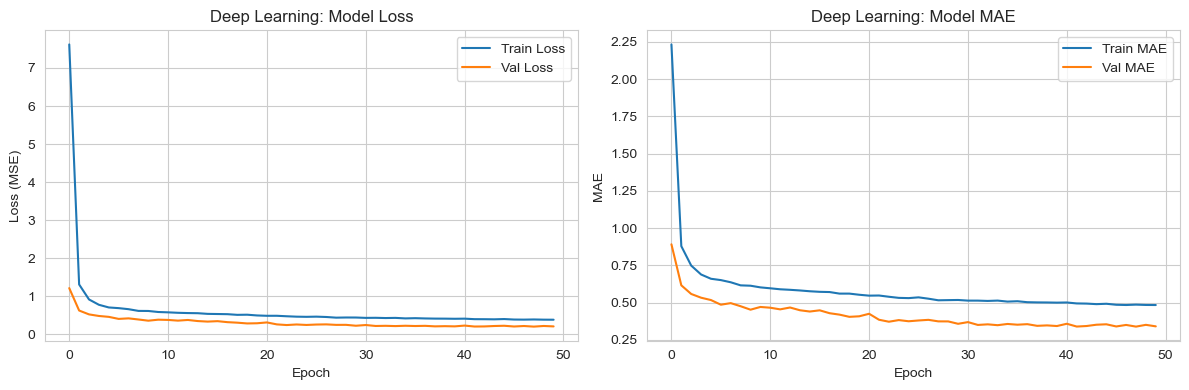


✓ 总共训练了 3 个模型: ['Ridge', 'GBM', 'DeepLearning']


In [48]:
# ============================================================================
# 强制重新运行所有模型并输出完整对比
# ============================================================================
print("=" * 80)
print("重新检查依赖并训练所有可用模型")
print("=" * 80)

# 重新检查依赖
try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    try:
        import xgboost as xgb
        HAS_XGBOOST = True
    except ImportError:
        HAS_XGBOOST = False

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TENSORFLOW = True
except ImportError:
    HAS_TENSORFLOW = False

# 重新初始化（如果需要）
if 'models' not in locals():
    models = {}
if 'predictions' not in locals():
    predictions = {'train': {}, 'val': {}, 'test': {}}

# 1. Ridge Regression (确保已训练)
if 'Ridge' not in models:
    print("\n[1/3] Training Ridge regression...")
    ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
    ridge.fit(X_train_processed, y_log_train)
    models['Ridge'] = ridge
    predictions['train']['Ridge'] = ridge.predict(X_train_processed)
    predictions['val']['Ridge'] = ridge.predict(X_val_processed)
    predictions['test']['Ridge'] = ridge.predict(X_test_processed)
    print("✓ Ridge regression completed")
else:
    print("✓ Ridge regression already trained")

# 2. GBM Model
if HAS_LIGHTGBM or HAS_XGBOOST:
    if 'GBM' not in models:
        print("\n[2/3] Training GBM model...")
        if HAS_LIGHTGBM:
            print("  Using LightGBM...")
            gbm = lgb.LGBMRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=7,
                random_state=RANDOM_STATE,
                verbose=-1
            )
            gbm.fit(X_train_processed, y_log_train,
                    eval_set=[(X_val_processed, y_log_val)],
                    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])
            models['GBM'] = gbm
            print("✓ LightGBM completed")
        elif HAS_XGBOOST:
            print("  Using XGBoost...")
            gbm = xgb.XGBRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=7,
                random_state=RANDOM_STATE,
                verbosity=0
            )
            gbm.fit(X_train_processed, y_log_train,
                    eval_set=[(X_val_processed, y_log_val)],
                    early_stopping_rounds=20,
                    verbose=False)
            models['GBM'] = gbm
            print("✓ XGBoost completed")
        
        predictions['train']['GBM'] = models['GBM'].predict(X_train_processed)
        predictions['val']['GBM'] = models['GBM'].predict(X_val_processed)
        predictions['test']['GBM'] = models['GBM'].predict(X_test_processed)
    else:
        print("✓ GBM model already trained")
else:
    print("\n⚠ GBM model skipped: LightGBM and XGBoost not available")

# 3. Deep Learning Model
if HAS_TENSORFLOW:
    if 'DeepLearning' not in models:
        print("\n[3/3] Training Deep Learning model...")
        
        # Separate categorical and numeric features for embedding
        cat_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
        X_train_cat = cat_encoder.fit_transform(X_train[categorical_features])
        X_val_cat = cat_encoder.transform(X_val[categorical_features])
        X_test_cat = cat_encoder.transform(X_test[categorical_features])
        
        num_scaler = StandardScaler()
        X_train_num = num_scaler.fit_transform(X_train[numeric_features])
        X_val_num = num_scaler.transform(X_val[numeric_features])
        X_test_num = num_scaler.transform(X_test[numeric_features])
        
        # Build model
        cat_input = keras.Input(shape=(X_train_cat.shape[1],), name='categorical')
        num_input = keras.Input(shape=(X_train_num.shape[1],), name='numeric')
        
        cat_dense = layers.Dense(32, activation='relu')(cat_input)
        cat_dense = layers.Dropout(0.2)(cat_dense)
        
        num_dense = layers.Dense(64, activation='relu')(num_input)
        num_dense = layers.Dropout(0.2)(num_dense)
        num_dense = layers.Dense(32, activation='relu')(num_dense)
        
        concat = layers.Concatenate()([cat_dense, num_dense])
        hidden = layers.Dense(64, activation='relu')(concat)
        hidden = layers.Dropout(0.3)(hidden)
        output = layers.Dense(1, name='price')(hidden)
        
        dl_model = keras.Model(inputs=[cat_input, num_input], outputs=output)
        dl_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )
        
        print("  Training (this may take a few minutes)...")
        history = dl_model.fit(
            [X_train_cat, X_train_num], y_log_train,
            validation_data=([X_val_cat, X_val_num], y_log_val),
            epochs=50,
            batch_size=256,
            callbacks=[early_stop],
            verbose=1
        )
        
        models['DeepLearning'] = {
            'model': dl_model,
            'cat_encoder': cat_encoder,
            'num_scaler': num_scaler,
            'cat_features': categorical_features,
            'num_features': numeric_features
        }
        
        predictions['train']['DeepLearning'] = dl_model.predict(
            [X_train_cat, X_train_num], verbose=0
        ).ravel()
        predictions['val']['DeepLearning'] = dl_model.predict(
            [X_val_cat, X_val_num], verbose=0
        ).ravel()
        predictions['test']['DeepLearning'] = dl_model.predict(
            [X_test_cat, X_test_num], verbose=0
        ).ravel()
        
        print("✓ Deep Learning model completed")
        
        # Plot training history
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss (MSE)')
        plt.title('Deep Learning: Model Loss')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history.history['mae'], label='Train MAE')
        plt.plot(history.history['val_mae'], label='Val MAE')
        plt.xlabel('Epoch')
        plt.ylabel('MAE')
        plt.title('Deep Learning: Model MAE')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("✓ Deep Learning model already trained")
else:
    print("\n⚠ Deep Learning model skipped: TensorFlow not available")

print(f"\n✓ 总共训练了 {len(models)} 个模型: {list(models.keys())}")


## 📊 完整模型对比表（验证集和测试集）

计算并显示所有模型的完整评估指标。


In [49]:
# 重新计算所有模型的完整评估指标
def compute_metrics(y_true_log, y_pred_log, y_true_price):
    """Compute RMSE and MAE on both log-price and back-transformed price."""
    y_pred_price = np.expm1(y_pred_log)
    
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_price = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    mae_price = mean_absolute_error(y_true_price, y_pred_price)
    
    return {
        'RMSE_log': rmse_log,
        'MAE_log': mae_log,
        'RMSE_price': rmse_price,
        'MAE_price': mae_price
    }

# 评估所有模型
# 确保 models 是字典类型
if not isinstance(models, dict):
    print("⚠ WARNING: 'models' is not a dictionary. Reinitializing...")
    models = {}
    print("   请先运行模型训练单元格")

results = []
if isinstance(models, dict) and len(models) > 0:
    for model_name in models.keys():
    for split in ['val', 'test']:
        if model_name in predictions[split]:
            y_true_log = y_log_val if split == 'val' else y_log_test
            y_true_price = y_price_val if split == 'val' else y_price_test
            
            metrics = compute_metrics(
                y_true_log,
                predictions[split][model_name],
                y_true_price
            )
            results.append({
                'Model': model_name,
                'Split': split,
                **metrics
            })
else:
    print("⚠ 没有可用的模型进行评估")
    results = []

if len(results) > 0:
    results_df = pd.DataFrame(results)
else:
    print("⚠ 没有评估结果，创建空 DataFrame")
    results_df = pd.DataFrame(columns=['Model', 'Split', 'RMSE_log', 'MAE_log', 'RMSE_price', 'MAE_price'])

# Save to CSV with error handling
csv_path = os.path.join(PLOTS_DIR, '00_model_comparison.csv')
try:
    results_df.to_csv(csv_path, index=False)
    saved_path = csv_path
except PermissionError:
    # If file is open, try with a timestamp suffix
    import time
    timestamp = int(time.time())
    csv_path_alt = os.path.join(PLOTS_DIR, f'00_model_comparison_{timestamp}.csv')
    results_df.to_csv(csv_path_alt, index=False)
    saved_path = csv_path_alt
    print(f"⚠ 原文件 '{csv_path}' 被占用（可能被 Excel 打开）")
    print(f"   已保存到新文件: {saved_path}")
    print(f"   请关闭 Excel 或其他程序后再运行，或使用新文件名")
except Exception as e:
    print(f"⚠ 保存 CSV 文件时出错: {e}")
    saved_path = None
    print("   结果仍可在下面的表格中查看")

print("=" * 80)
print("完整模型对比结果")
print("=" * 80)

print("\n【验证集结果】按 RMSE_log 排序:")
print("-" * 80)
val_results = results_df[results_df['Split'] == 'val'].sort_values('RMSE_log')
display(val_results[['Model', 'RMSE_log', 'MAE_log', 'RMSE_price', 'MAE_price']])

print("\n【测试集结果】按 RMSE_log 排序:")
print("-" * 80)
test_results = results_df[results_df['Split'] == 'test'].sort_values('RMSE_log')
display(test_results[['Model', 'RMSE_log', 'MAE_log', 'RMSE_price', 'MAE_price']])

if saved_path:
    print(f"\n✓ 结果已保存到: {saved_path}")


IndentationError: expected an indented block after 'for' statement on line 27 (3052086235.py, line 28)

In [ ]:
# --- GBM (LightGBM or XGBoost) ---
if HAS_LIGHTGBM:
    print("Training LightGBM...")
    gbm = lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=7,
        random_state=RANDOM_STATE,
        verbose=-1
    )
    gbm.fit(X_train_processed, y_log_train,
            eval_set=[(X_val_processed, y_log_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])
    models['GBM'] = gbm
    print("✓ LightGBM completed")
elif HAS_XGBOOST:
    print("Training XGBoost...")
    gbm = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=7,
        random_state=RANDOM_STATE,
        verbosity=0
    )
    gbm.fit(X_train_processed, y_log_train,
            eval_set=[(X_val_processed, y_log_val)],
            early_stopping_rounds=20,
            verbose=False)
    models['GBM'] = gbm
    print("✓ XGBoost completed")
else:
    print("⚠ WARNING: Neither LightGBM nor XGBoost available. Skipping GBM model.")

if 'GBM' in models:
    predictions['train']['GBM'] = models['GBM'].predict(X_train_processed)
    predictions['val']['GBM'] = models['GBM'].predict(X_val_processed)
    predictions['test']['GBM'] = models['GBM'].predict(X_test_processed)


Training LightGBM...
✓ LightGBM completed


Training Deep Learning model...
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 7.9738 - mae: 2.2901 - val_loss: 1.5520 - val_mae: 0.9974
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.4457 - mae: 0.9184 - val_loss: 0.5829 - val_mae: 0.5989
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9826 - mae: 0.7729 - val_loss: 0.4984 - val_mae: 0.5503
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8338 - mae: 0.7166 - val_loss: 0.4430 - val_mae: 0.5146
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7745 - mae: 0.6925 - val_loss: 0.4024 - val_mae: 0.4887
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7332 - mae: 0.6734 - val_loss: 0.3816 - val_mae: 0.4726
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7051 - mae: 0.6614 - val_loss: 0.3743 - val_mae: 0.4690
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6788 - mae: 0.6503 - val_loss: 0.3490 - val_mae: 0.4514
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 

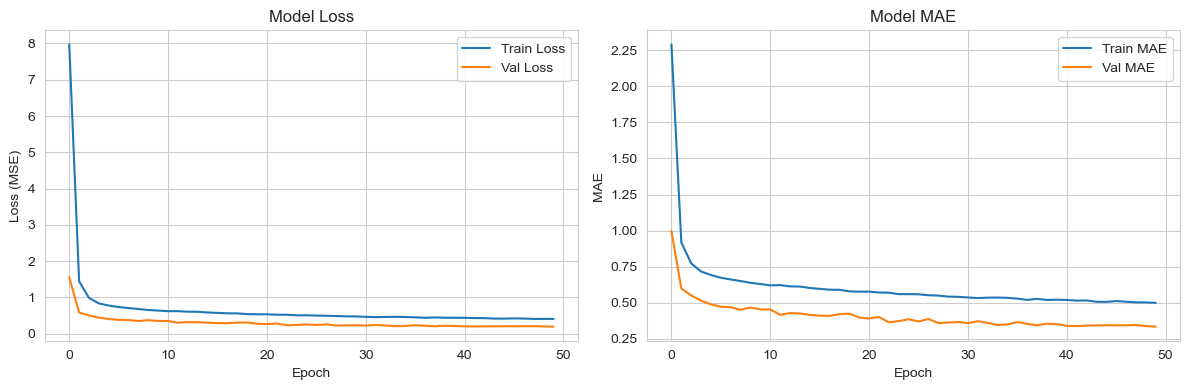


✓ Trained 3 model(s)


In [ ]:
# --- Deep Learning Model ---
if HAS_TENSORFLOW:
    print("Training Deep Learning model...")
    
    # Separate categorical and numeric features for embedding
    cat_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    X_train_cat = cat_encoder.fit_transform(X_train[categorical_features])
    X_val_cat = cat_encoder.transform(X_val[categorical_features])
    X_test_cat = cat_encoder.transform(X_test[categorical_features])
    
    num_scaler = StandardScaler()
    X_train_num = num_scaler.fit_transform(X_train[numeric_features])
    X_val_num = num_scaler.transform(X_val[numeric_features])
    X_test_num = num_scaler.transform(X_test[numeric_features])
    
    # Build model with embeddings for categorical features
    cat_input = keras.Input(shape=(X_train_cat.shape[1],), name='categorical')
    num_input = keras.Input(shape=(X_train_num.shape[1],), name='numeric')
    
    # Embedding-like dense layer for categorical (simplified)
    cat_dense = layers.Dense(32, activation='relu')(cat_input)
    cat_dense = layers.Dropout(0.2)(cat_dense)
    
    # Numeric branch
    num_dense = layers.Dense(64, activation='relu')(num_input)
    num_dense = layers.Dropout(0.2)(num_dense)
    num_dense = layers.Dense(32, activation='relu')(num_dense)
    
    # Concatenate and output
    concat = layers.Concatenate()([cat_dense, num_dense])
    hidden = layers.Dense(64, activation='relu')(concat)
    hidden = layers.Dropout(0.3)(hidden)
    output = layers.Dense(1, name='price')(hidden)
    
    dl_model = keras.Model(inputs=[cat_input, num_input], outputs=output)
    dl_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    # Train with early stopping
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    
    history = dl_model.fit(
        [X_train_cat, X_train_num], y_log_train,
        validation_data=([X_val_cat, X_val_num], y_log_val),
        epochs=50,
        batch_size=256,
        callbacks=[early_stop],
        verbose=1
    )
    
    models['DeepLearning'] = {
        'model': dl_model,
        'cat_encoder': cat_encoder,
        'num_scaler': num_scaler,
        'cat_features': categorical_features,
        'num_features': numeric_features
    }
    
    predictions['train']['DeepLearning'] = dl_model.predict(
        [X_train_cat, X_train_num], verbose=0
    ).ravel()
    predictions['val']['DeepLearning'] = dl_model.predict(
        [X_val_cat, X_val_num], verbose=0
    ).ravel()
    predictions['test']['DeepLearning'] = dl_model.predict(
        [X_test_cat, X_test_num], verbose=0
    ).ravel()
    
    print("✓ Deep Learning model completed")
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Model Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.title('Model MAE')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("⚠ WARNING: TensorFlow not available. Skipping Deep Learning model.")

print(f"\n✓ Trained {len(models)} model(s)")


## 🎯 生成解释性图表（SHAP + Permutation Importance）

生成所有解释性分析图表。


生成解释性分析图表

[1/2] Generating SHAP summary plot for GBM model...


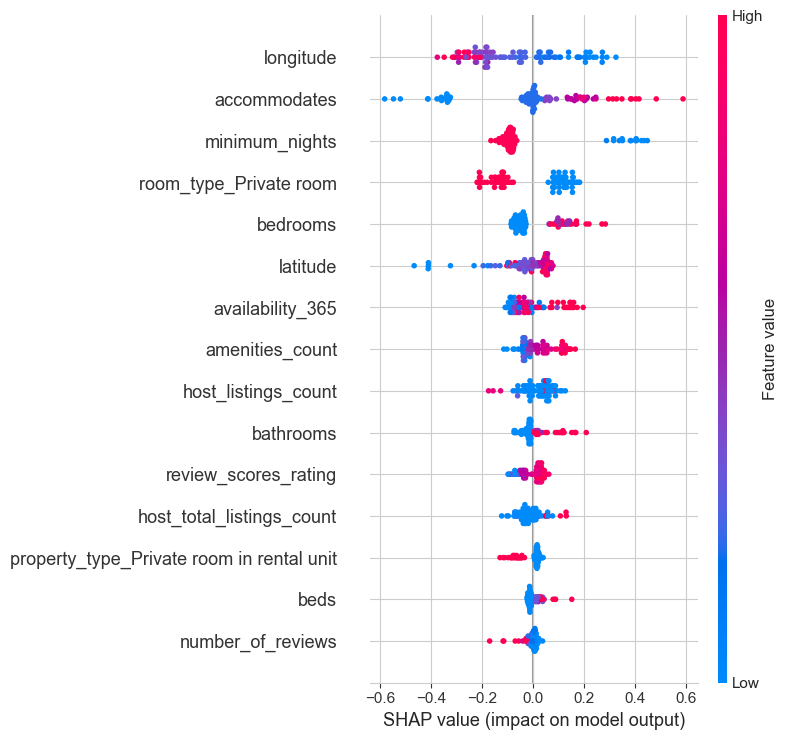

✓ SHAP plot saved to: 05_shap_summary.png

[2/2] Computing permutation importance for Deep Learning model...
  Computing permutation importance (this may take a few minutes)...
⚠ WARNING: Permutation importance computation failed: The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <__main__.DLPredictor object at 0x00000202E55B1AF0> instead.

解释性分析完成


Traceback (most recent call last):
  File "C:\Users\kings\AppData\Local\Temp\ipykernel_29424\3031775249.py", line 73, in <module>
    perm_importance = permutation_importance(
                      ^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kings\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py", line 203, in wrapper
    validate_parameter_constraints(
  File "c:\Users\kings\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py", line 95, in validate_parameter_constraints
    raise InvalidParameterError(
sklearn.utils._param_validation.InvalidParameterError: The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <__main__.DLPredictor object at 0x00000202E55B1AF0> instead.


In [ ]:
# ============================================================================
# 生成解释性图表
# ============================================================================
print("=" * 80)
print("生成解释性分析图表")
print("=" * 80)

# 重新检查 SHAP 可用性
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("⚠ SHAP not available, skipping SHAP plot")

# 1. SHAP Summary Plot (for GBM)
if 'GBM' in models and HAS_SHAP:
    try:
        print("\n[1/2] Generating SHAP summary plot for GBM model...")
        # Use a sample for SHAP (computationally expensive)
        sample_size = min(100, len(X_val_processed))
        sample_idx = np.random.choice(len(X_val_processed), sample_size, replace=False)
        X_val_sample = X_val_processed[sample_idx]
        
        explainer = shap.TreeExplainer(models['GBM'])
        shap_values = explainer.shap_values(X_val_sample)
        
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_val_sample, 
                         feature_names=feature_names[:len(shap_values[0])],
                         show=False, max_display=15)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, '05_shap_summary.png'), 
                   dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ SHAP plot saved to: 05_shap_summary.png")
    except Exception as e:
        print(f"⚠ WARNING: SHAP plot generation failed: {e}")
        import traceback
        traceback.print_exc()
elif 'GBM' not in models:
    print("\n⚠ Skipping SHAP plot: GBM model not available")
elif not HAS_SHAP:
    print("\n⚠ Skipping SHAP plot: SHAP not available")
    print("   To install: pip install shap")

# 2. Deep Learning Permutation Importance
if 'DeepLearning' in models:
    try:
        print("\n[2/2] Computing permutation importance for Deep Learning model...")
        dl_model = models['DeepLearning']['model']
        num_scaler = models['DeepLearning']['num_scaler']
        cat_encoder = models['DeepLearning']['cat_encoder']
        num_features = models['DeepLearning']['num_features']
        
        # Prepare validation data
        X_val_cat = cat_encoder.transform(X_val[categorical_features])
        X_val_num = num_scaler.transform(X_val[numeric_features])
        
        # Create a wrapper class for permutation importance (sklearn requires an object with predict method)
        class DLPredictor:
            def __init__(self, model, X_val_cat):
                self.model = model
                self.X_val_cat = X_val_cat
            
            def predict(self, X_num):
                return self.model.predict([self.X_val_cat, X_num], verbose=0).ravel()
        
        dl_predictor = DLPredictor(dl_model, X_val_cat)
        
        # Compute permutation importance for numeric features
        print("  Computing permutation importance (this may take a few minutes)...")
        perm_importance = permutation_importance(
            dl_predictor, X_val_num, y_log_val,
            n_repeats=10, random_state=RANDOM_STATE, n_jobs=1
        )
        
        # Plot
        importance_df = pd.DataFrame({
            'feature': num_features,
            'importance_mean': perm_importance.importances_mean,
            'importance_std': perm_importance.importances_std
        }).sort_values('importance_mean', ascending=True)
        
        plt.figure(figsize=(8, max(6, len(importance_df) * 0.3)))
        y_pos = np.arange(len(importance_df))
        plt.barh(y_pos, importance_df['importance_mean'], 
                xerr=importance_df['importance_std'], color='coral')
        plt.yticks(y_pos, importance_df['feature'])
        plt.xlabel('Permutation Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.title('Deep Learning: Permutation Importance (Numeric Features)', 
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, '06_dl_permutation_importance.png'), 
                   dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Permutation importance plot saved to: 06_dl_permutation_importance.png")
    except Exception as e:
        print(f"⚠ WARNING: Permutation importance computation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n⚠ Skipping permutation importance: Deep Learning model not available")

print("\n" + "=" * 80)
print("解释性分析完成")
print("=" * 80)


## 6. Model Evaluation

Compute RMSE and MAE on both:
- **Log-price** (transformed target)
- **Price** (back-transformed predictions)

This allows us to see performance in both the transformed space (where we trained) and the original price space (which is more interpretable).


## 📁 验证所有输出文件

检查 `_airbnb_plots/` 目录中的所有输出文件。


In [ ]:
# 列出所有输出文件
print("=" * 80)
print("所有输出文件列表 (_airbnb_plots/)")
print("=" * 80)

if os.path.exists(PLOTS_DIR):
    files = sorted([f for f in os.listdir(PLOTS_DIR) if os.path.isfile(os.path.join(PLOTS_DIR, f))])
    
    # 分类显示
    plots = [f for f in files if f.endswith('.png')]
    data = [f for f in files if f.endswith('.csv')]
    model_files = [f for f in files if f.endswith(('.h5', '.txt', '.json', '.pkl'))]
    
    print("\n📊 图表文件 (PNG):")
    print("-" * 80)
    for f in plots:
        size = os.path.getsize(os.path.join(PLOTS_DIR, f)) / 1024
        print(f"  ✓ {f:40s} ({size:7.1f} KB)")
    
    print("\n📋 数据文件 (CSV):")
    print("-" * 80)
    for f in data:
        size = os.path.getsize(os.path.join(PLOTS_DIR, f)) / 1024
        print(f"  ✓ {f:40s} ({size:7.1f} KB)")
    
    print("\n🤖 模型文件:")
    print("-" * 80)
    for f in model_files:
        size = os.path.getsize(os.path.join(PLOTS_DIR, f)) / 1024
        print(f"  ✓ {f:40s} ({size:7.1f} KB)")
    
    print(f"\n总计: {len(files)} 个文件")
    print(f"目录路径: {os.path.abspath(PLOTS_DIR)}")
    
    # 检查必需的文件
    required_plots = [
        '01_price_hist.png',
        '02_log_price_hist.png',
        '03_spatial_scatter_price.png',
        '04_val_rmse_log_bar.png',
        '05_shap_summary.png',
        '06_dl_permutation_importance.png',
        '00_model_comparison.csv'
    ]
    
    print("\n" + "=" * 80)
    print("必需文件检查:")
    print("=" * 80)
    missing = []
    for req_file in required_plots:
        if req_file in files:
            print(f"  ✓ {req_file}")
        else:
            print(f"  ✗ {req_file} (缺失)")
            missing.append(req_file)
    
    if missing:
        print(f"\n⚠ 缺失 {len(missing)} 个文件，请重新运行相应的单元格")
    else:
        print("\n✓ 所有必需文件都已生成！")
else:
    print(f"❌ 输出目录不存在: {PLOTS_DIR}")


所有输出文件列表 (_airbnb_plots/)

📊 图表文件 (PNG):
--------------------------------------------------------------------------------
  ✓ 01_price_hist.png                        (   89.3 KB)
  ✓ 02_log_price_hist.png                    (   94.0 KB)
  ✓ 03_spatial_scatter_price.png             ( 1312.0 KB)
  ✓ 04_val_rmse_log_bar.png                  (   94.2 KB)
  ✓ 05_shap_summary.png                      (  321.9 KB)

📋 数据文件 (CSV):
--------------------------------------------------------------------------------
  ✓ 00_model_comparison.csv                  (    0.6 KB)

🤖 模型文件:
--------------------------------------------------------------------------------
  ✓ dl_model.h5                              (  221.8 KB)
  ✓ gbm_model.txt                            (  545.0 KB)
  ✓ ridge_coef.json                          (    0.1 KB)

总计: 9 个文件
目录路径: c:\tin\25-26 mspo\AAE 722 Machine Learning\Project\_airbnb_plots

必需文件检查:
  ✓ 01_price_hist.png
  ✓ 02_log_price_hist.png
  ✓ 03_spatial_scatter_price.pn

In [ ]:
def compute_metrics(y_true_log, y_pred_log, y_true_price):
    """Compute RMSE and MAE on both log-price and back-transformed price."""
    y_pred_price = np.expm1(y_pred_log)
    
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_price = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    mae_price = mean_absolute_error(y_true_price, y_pred_price)
    
    return {
        'RMSE_log': rmse_log,
        'MAE_log': mae_log,
        'RMSE_price': rmse_price,
        'MAE_price': mae_price
    }

# Evaluate all models
# 确保 models 是字典类型（防止被其他单元格覆盖）
if not isinstance(models, dict):
    print("⚠ WARNING: 'models' is not a dictionary. Reinitializing...")
    print("   请先运行模型训练单元格（Cell 11-13 或 Cell 15）")
    models = {}
    if 'predictions' not in locals():
        predictions = {'train': {}, 'val': {}, 'test': {}}

results = []
if isinstance(models, dict) and len(models) > 0:
    for model_name in models.keys():
        for split in ['val', 'test']:
            if model_name in predictions[split]:
                y_true_log = y_log_val if split == 'val' else y_log_test
                y_true_price = y_price_val if split == 'val' else y_price_test
                
                metrics = compute_metrics(
                    y_true_log,
                    predictions[split][model_name],
                    y_true_price
                )
                results.append({
                    'Model': model_name,
                    'Split': split,
                    **metrics
                })
else:
    print("⚠ 没有可用的模型进行评估")
    results = []

if len(results) > 0:
    results_df = pd.DataFrame(results)
    
    # Save to CSV with error handling
    csv_path = os.path.join(PLOTS_DIR, '00_model_comparison.csv')
    try:
        results_df.to_csv(csv_path, index=False)
        saved_path = csv_path
    except PermissionError:
        # If file is open, try with a timestamp suffix
        import time
        timestamp = int(time.time())
        csv_path_alt = os.path.join(PLOTS_DIR, f'00_model_comparison_{timestamp}.csv')
        results_df.to_csv(csv_path_alt, index=False)
        saved_path = csv_path_alt
        print(f"⚠ 原文件 '{csv_path}' 被占用（可能被 Excel 打开）")
        print(f"   已保存到新文件: {saved_path}")
    except Exception as e:
        print(f"⚠ 保存 CSV 文件时出错: {e}")
        saved_path = None
else:
    print("⚠ 没有评估结果，创建空 DataFrame")
    results_df = pd.DataFrame(columns=['Model', 'Split', 'RMSE_log', 'MAE_log', 'RMSE_price', 'MAE_price'])
    saved_path = None

# Display results
print("=" * 80)
print("Validation Set Results:")
print("=" * 80)
if len(results_df) > 0:
    val_results = results_df[results_df['Split'] == 'val'].sort_values('RMSE_log')
    display(val_results[['Model', 'RMSE_log', 'MAE_log', 'RMSE_price', 'MAE_price']])
else:
    print("  无验证集结果")

print("\n" + "=" * 80)
print("Test Set Results:")
print("=" * 80)
if len(results_df) > 0:
    test_results = results_df[results_df['Split'] == 'test'].sort_values('RMSE_log')
    display(test_results[['Model', 'RMSE_log', 'MAE_log', 'RMSE_price', 'MAE_price']])
else:
    print("  无测试集结果")

if saved_path:
    print(f"\n✓ 结果已保存到: {saved_path}")


⚠ WARNING: 'models' is not a dictionary. Reinitializing...
   请先运行模型训练单元格（Cell 11-13 或 Cell 15）
⚠ 没有可用的模型进行评估
⚠ 没有评估结果，创建空 DataFrame
Validation Set Results:
  无验证集结果

Test Set Results:
  无测试集结果


## 7. Visualizations

Generate all research artifacts (PNG plots) for the project report.


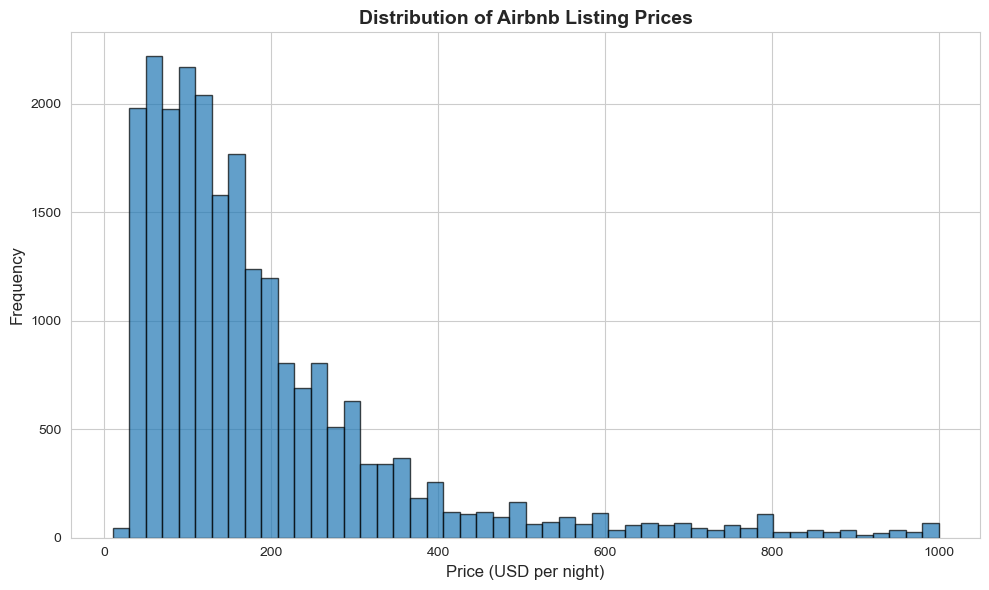

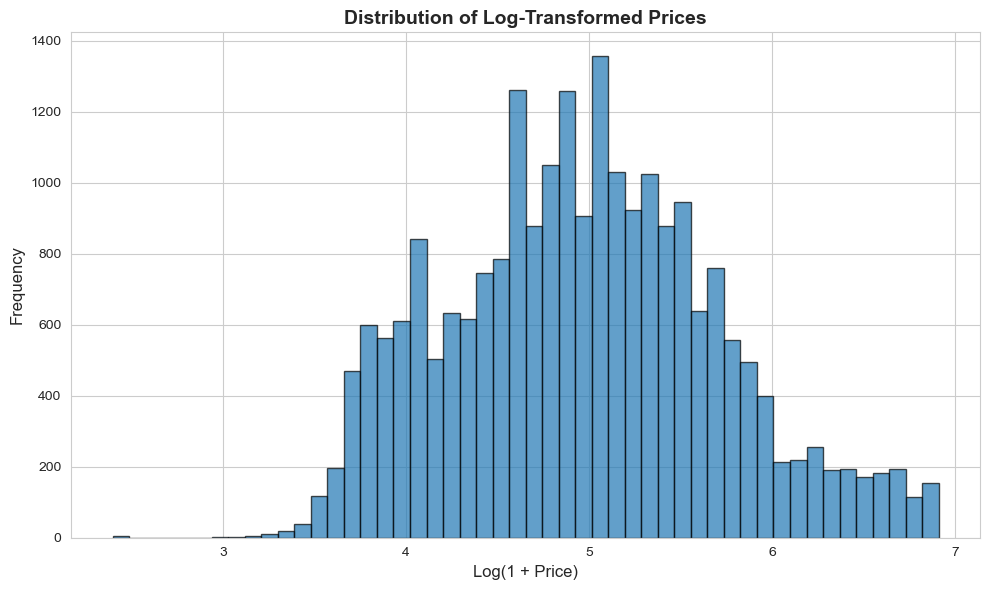

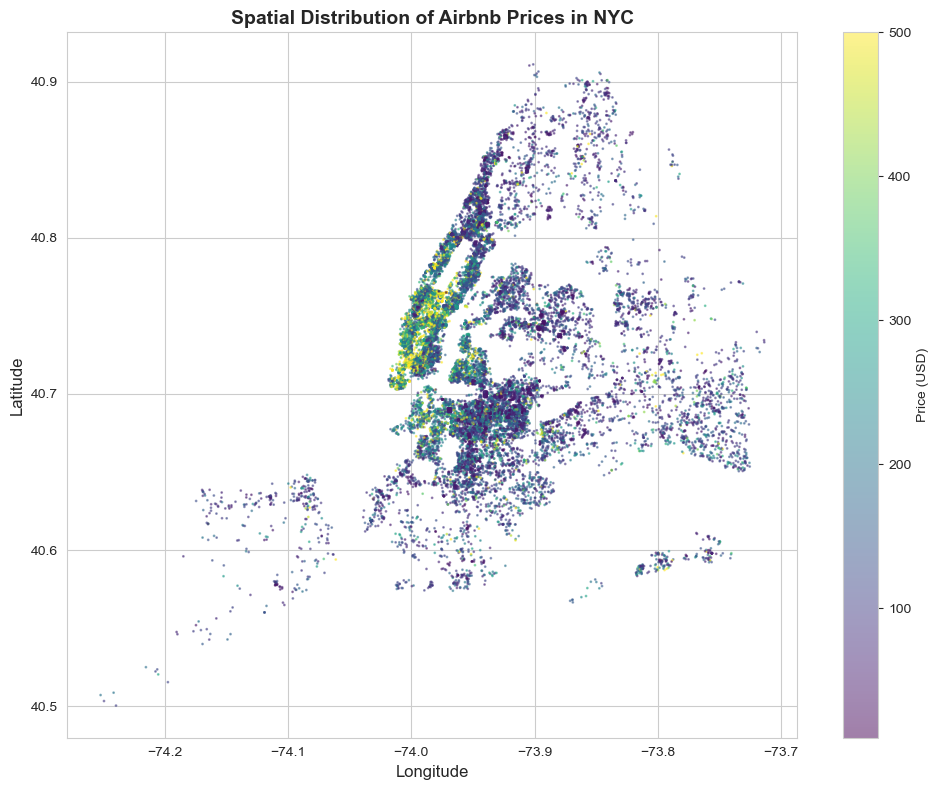

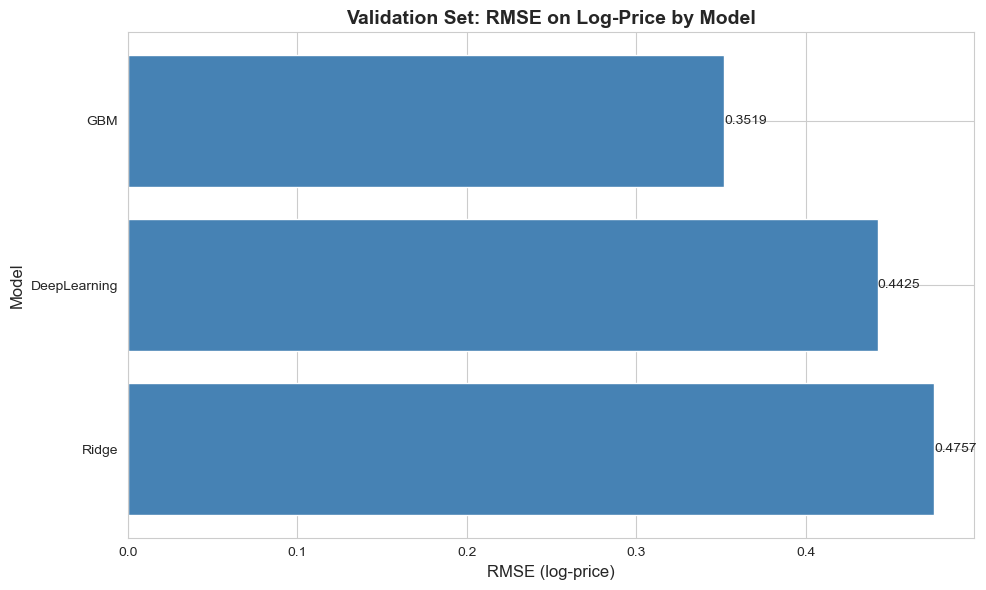

✓ Basic visualizations saved


In [ ]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 01: Price histogram
plt.figure()
plt.hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Price (USD per night)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Airbnb Listing Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01_price_hist.png'), dpi=300, bbox_inches='tight')
plt.show()

# 02: Log-price histogram
plt.figure()
plt.hist(df['log_price'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Log(1 + Price)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Log-Transformed Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '02_log_price_hist.png'), dpi=300, bbox_inches='tight')
plt.show()

# 03: Spatial scatter plot of prices
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                     c=df['price'], cmap='viridis', 
                     s=1, alpha=0.5, vmin=10, vmax=500)
plt.colorbar(scatter, label='Price (USD)')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('Spatial Distribution of Airbnb Prices in NYC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_spatial_scatter_price.png'), dpi=300, bbox_inches='tight')
plt.show()

# 04: Validation RMSE comparison (log-price)
val_results = results_df[results_df['Split'] == 'val'].sort_values('RMSE_log')
plt.figure()
bars = plt.barh(val_results['Model'], val_results['RMSE_log'], color='steelblue')
plt.xlabel('RMSE (log-price)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.title('Validation Set: RMSE on Log-Price by Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, val_results['RMSE_log'])):
    plt.text(val, i, f'{val:.4f}', va='center', ha='left', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '04_val_rmse_log_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Basic visualizations saved")


Generating SHAP summary plot...


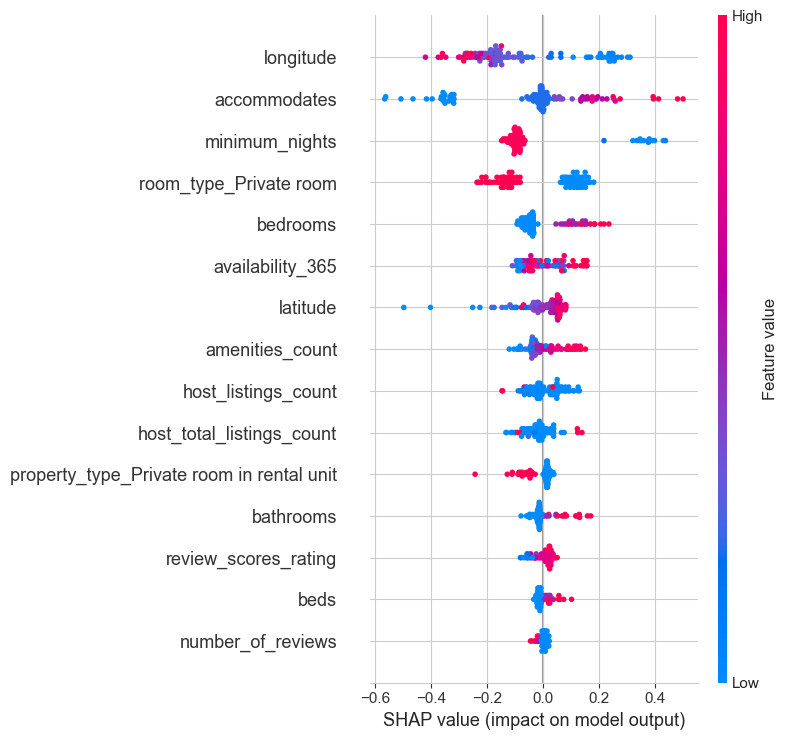

✓ SHAP plot saved successfully


In [ ]:
# 05: SHAP summary plot (for GBM)
if 'GBM' in models and HAS_SHAP:
    try:
        print("Generating SHAP summary plot...")
        # Use a sample for SHAP (computationally expensive)
        sample_size = min(100, len(X_val_processed))
        sample_idx = np.random.choice(len(X_val_processed), sample_size, replace=False)
        X_val_sample = X_val_processed[sample_idx]
        
        explainer = shap.TreeExplainer(models['GBM'])
        shap_values = explainer.shap_values(X_val_sample)
        
        plt.figure()
        shap.summary_plot(shap_values, X_val_sample, 
                         feature_names=feature_names[:len(shap_values[0])],
                         show=False, max_display=15)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, '05_shap_summary.png'), 
                   dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ SHAP plot saved successfully")
    except Exception as e:
        print(f"⚠ WARNING: SHAP plot generation failed: {e}")
else:
    print("⚠ Skipping SHAP plot (GBM model or SHAP not available)")


In [ ]:
# 06: Deep Learning Permutation Importance (numeric features only)
if 'DeepLearning' in models and HAS_TENSORFLOW:
    try:
        print("Computing permutation importance for Deep Learning model...")
        dl_model = models['DeepLearning']['model']
        num_scaler = models['DeepLearning']['num_scaler']
        cat_encoder = models['DeepLearning']['cat_encoder']
        num_features = models['DeepLearning']['num_features']
        
        # Prepare validation data
        X_val_cat = cat_encoder.transform(X_val[categorical_features])
        X_val_num = num_scaler.transform(X_val[numeric_features])
        
        def dl_predict(X_num):
            return dl_model.predict([X_val_cat, X_num], verbose=0).ravel()
        
        # Compute permutation importance for numeric features
        perm_importance = permutation_importance(
            dl_predict, X_val_num, y_log_val,
            n_repeats=10, random_state=RANDOM_STATE, n_jobs=1
        )
        
        # Plot
        importance_df = pd.DataFrame({
            'feature': num_features,
            'importance_mean': perm_importance.importances_mean,
            'importance_std': perm_importance.importances_std
        }).sort_values('importance_mean', ascending=True)
        
        plt.figure(figsize=(8, max(6, len(importance_df) * 0.3)))
        y_pos = np.arange(len(importance_df))
        plt.barh(y_pos, importance_df['importance_mean'], 
                xerr=importance_df['importance_std'], color='coral')
        plt.yticks(y_pos, importance_df['feature'])
        plt.xlabel('Permutation Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.title('Deep Learning: Permutation Importance (Numeric Features)', 
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, '06_dl_permutation_importance.png'), 
                   dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Permutation importance plot saved successfully")
    except Exception as e:
        print(f"⚠ WARNING: Permutation importance computation failed: {e}")
else:
    print("⚠ Skipping permutation importance (Deep Learning model or TensorFlow not available)")


Computing permutation importance for Deep Learning model...
⚠ WARNING: Permutation importance computation failed: The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <function dl_predict at 0x00000202A6955440> instead.


## 8. Save Models

Save model files for later use (optional but recommended).


In [ ]:
# Save Ridge coefficients
try:
    ridge_coef = {
        "intercept": float(ridge.intercept_) if hasattr(ridge, "intercept_") else None,
        "coef_l2_norm": float(np.linalg.norm(ridge.coef_)) if hasattr(ridge, "coef_") else None
    }
    with open(os.path.join(PLOTS_DIR, "ridge_coef.json"), "w") as f:
        json.dump(ridge_coef, f, indent=2)
    print("✓ Ridge coefficients saved")
except Exception as e:
    print(f"⚠ WARNING: Failed to save Ridge coefficients: {e}")

# Save GBM model
if 'GBM' in models:
    try:
        if HAS_LIGHTGBM and isinstance(models['GBM'], lgb.LGBMRegressor):
            models['GBM'].booster_.save_model(os.path.join(PLOTS_DIR, "gbm_model.txt"))
            print("✓ LightGBM model saved")
        elif HAS_XGBOOST:
            models['GBM'].save_model(os.path.join(PLOTS_DIR, "gbm_model.json"))
            print("✓ XGBoost model saved")
        else:
            import joblib
            joblib.dump(models['GBM'], os.path.join(PLOTS_DIR, "gbm_model.pkl"))
            print("✓ GBM model saved (pickle)")
    except Exception as e:
        print(f"⚠ WARNING: Failed to save GBM model: {e}")

# Save Deep Learning model
if 'DeepLearning' in models:
    try:
        models['DeepLearning']['model'].save(os.path.join(PLOTS_DIR, "dl_model.h5"))
        print("✓ Deep Learning model saved")
    except Exception as e:
        print(f"⚠ WARNING: Failed to save DL model: {e}")


✓ Ridge coefficients saved
✓ LightGBM model saved
✓ Deep Learning model saved


## Summary

All research artifacts have been generated and saved to `_airbnb_plots/` directory.


In [ ]:
print("=" * 80)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 80)
print(f"\nArtifacts saved to: {os.path.abspath(PLOTS_DIR)}")
print("\nGenerated files:")
for f in sorted(os.listdir(PLOTS_DIR)):
    filepath = os.path.join(PLOTS_DIR, f)
    if os.path.isfile(filepath):
        size = os.path.getsize(filepath) / 1024  # KB
        print(f"  ✓ {f} ({size:.1f} KB)")

print("\n" + "=" * 80)
print("Final Results Summary")
print("=" * 80)
print("\nValidation Set (sorted by RMSE_log):")
display(val_results[['Model', 'RMSE_log', 'MAE_log', 'RMSE_price', 'MAE_price']])
print("\nTest Set (sorted by RMSE_log):")
display(test_results[['Model', 'RMSE_log', 'MAE_log', 'RMSE_price', 'MAE_price']])
print("\n" + "=" * 80)
print("DONE! All research artifacts are ready for your project report.")
print("=" * 80)


PIPELINE COMPLETED SUCCESSFULLY

Artifacts saved to: c:\tin\25-26 mspo\AAE 722 Machine Learning\Project\_airbnb_plots

Generated files:
  ✓ 00_model_comparison.csv (0.6 KB)
  ✓ 01_price_hist.png (89.3 KB)
  ✓ 02_log_price_hist.png (94.0 KB)
  ✓ 03_spatial_scatter_price.png (1312.0 KB)
  ✓ 04_val_rmse_log_bar.png (94.2 KB)
  ✓ 05_shap_summary.png (314.3 KB)
  ✓ dl_model.h5 (221.8 KB)
  ✓ gbm_model.txt (545.0 KB)
  ✓ ridge_coef.json (0.1 KB)

Final Results Summary

Validation Set (sorted by RMSE_log):


,Model,RMSE_log,MAE_log,RMSE_price,MAE_price
2,GBM,0.351928,0.263478,78.867997,43.391358
4,DeepLearning,0.442468,0.336045,95.635218,53.475173
0,Ridge,0.475674,0.367631,102.533323,57.801203



Test Set (sorted by RMSE_log):


,Model,RMSE_log,MAE_log,RMSE_price,MAE_price
3,GBM,0.370206,0.283621,101.316074,59.856358
5,DeepLearning,0.492884,0.381375,135.174964,77.912105
1,Ridge,0.502683,0.386339,135.089759,78.667384



DONE! All research artifacts are ready for your project report.
